# Exploratory Data Analysis on Retail Sales Data

## Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on retail sales data to understand customer behaviour, sales trends, product performance, and generate actionable business insights.

## 1. Import Libraries


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Upload Dataset


In [37]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive (5).zip


## 3. Extract Dataset


In [41]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("retail_data")

print(os.listdir("retail_data"))

['retail_sales_dataset.csv']


## 4. Load Dataset


In [42]:
df = pd.read_csv("retail_data/retail_sales_dataset.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## 5. Initial Data Inspection


In [43]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (1000, 9)

Columns:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

Data Types:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


## 6. Date Conversion


In [44]:
df["Date"] = pd.to_datetime(df["Date"])

print(df.dtypes)

Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object


### Date Conversion

The Date column was converted from text format to datetime format. This allows us to perform time-based analysis such as monthly and quarterly sales analysis.

## 7. Descriptive Statistics


In [40]:
# Descriptive statistics

numeric_columns = ["Age", "Quantity", "Price per Unit", "Total Amount"]

print("Mean:")
print(df[numeric_columns].mean())

print("\nMedian:")
print(df[numeric_columns].median())

print("\nMode:")
print(df[numeric_columns].mode().iloc[0])

print("\nStandard Deviation:")
print(df[numeric_columns].std())

Mean:
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

Median:
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

Mode:
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

Standard Deviation:
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


### Descriptive Statistics

The descriptive statistics were calculated for all numerical variables, including Age, Quantity, Price per Unit, and Total Amount. Mean and median help understand the central tendency, while standard deviation shows the variability in the data.

## 8. Gender Distribution


Gender
Female    510
Male      490
Name: count, dtype: int64


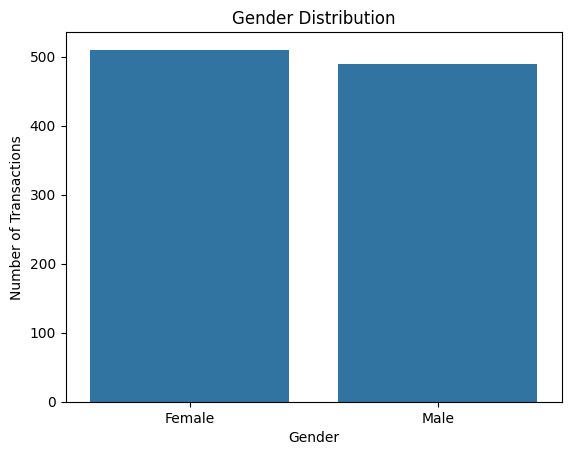

In [39]:
gender_counts = df["Gender"].value_counts()

print(gender_counts)

sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Transactions")
plt.show()

### Observation

Female customers made 510 transactions, while male customers made 490 transactions. The distribution is relatively balanced between the two genders.

## 9. Age Group Distribution


Age Group
18-25    169
26-35    205
36-45    202
46-55    229
56+      195
Name: count, dtype: int64


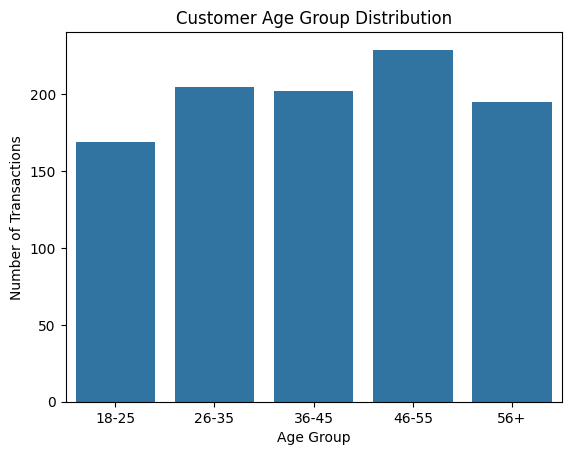

In [38]:
# Create age groups

bins = [18, 25, 35, 45, 55, 100]
labels = ["18-25", "26-35", "36-45", "46-55", "56+"]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

age_group_counts = df["Age Group"].value_counts().sort_index()

print(age_group_counts)

sns.barplot(
    x=age_group_counts.index,
    y=age_group_counts.values
)

plt.title("Customer Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Transactions")
plt.show()

### Observation

The 46–55 age group has the highest number of transactions, with 229 transactions, while the 18–25 age group has the lowest, with 169 transactions.

## 10. Revenue by Product Category


Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


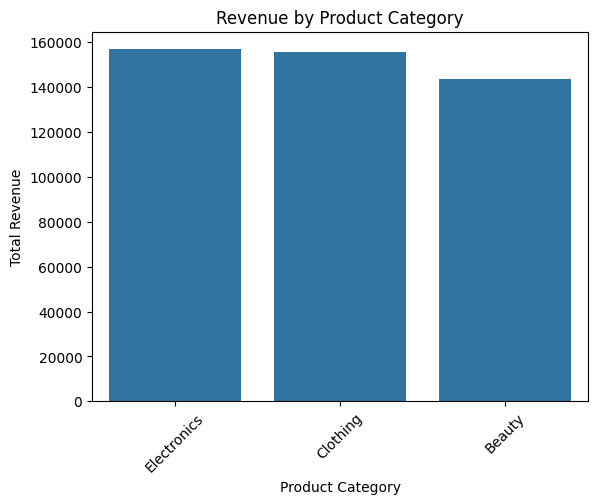

In [45]:
revenue = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

print(revenue)

sns.barplot(x=revenue.index, y=revenue.values)
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

### Observation
Electronics generated the highest revenue, followed closely by Clothing, while Beauty generated the lowest revenue among the three categories.

## 11. Monthly and Quarterly Sales


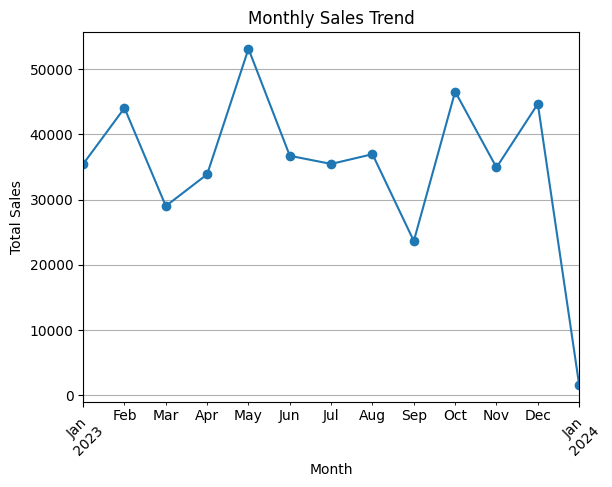

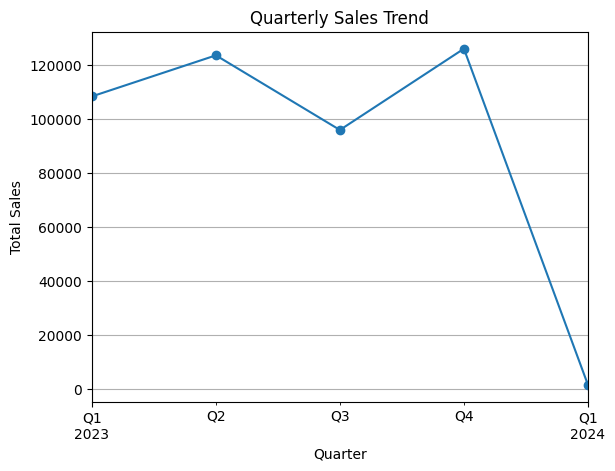

In [46]:
df["Month"] = df["Date"].dt.to_period("M")
monthly_sales = df.groupby("Month")["Total Amount"].sum()

df["Quarter"] = df["Date"].dt.to_period("Q")
quarterly_sales = df.groupby("Quarter")["Total Amount"].sum()

monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

quarterly_sales.plot(kind="line", marker="o")
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

### Observation
Sales fluctuate across months and quarters. May 2023 recorded the highest monthly sales, while Q4 2023 recorded the highest quarterly sales among the complete quarters of 2023.

## 12. Correlation Heatmap


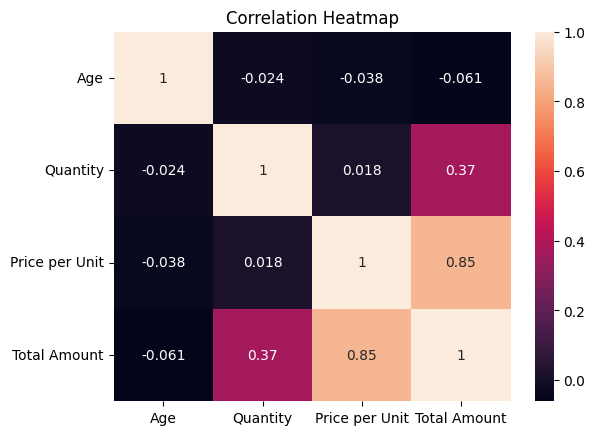

In [47]:
correlation = df[["Age", "Quantity", "Price per Unit", "Total Amount"]].corr()

sns.heatmap(correlation, annot=True)
plt.title("Correlation Heatmap")
plt.show()

### Observation
The correlation heatmap shows the relationships between the numerical variables. Total Amount has a positive relationship with Quantity and Price per Unit because both contribute directly to transaction value.


## 13. Age vs Total Amount


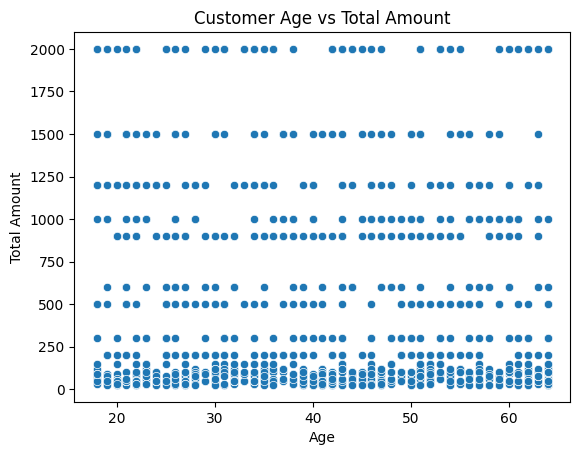

In [48]:
sns.scatterplot(data=df, x="Age", y="Total Amount")
plt.title("Customer Age vs Total Amount")
plt.xlabel("Age")
plt.ylabel("Total Amount")
plt.show()

### Observation
There is no obvious relationship between customer age and total transaction amount. Spending varies across different age groups, suggesting that age alone may not strongly predict transaction value.

# Conclusion and Business Recommendations

### Key Findings
- Electronics generated the highest revenue.
- The 46–55 age group had the highest number of transactions.
- Sales varied considerably across months and quarters.
- Average transaction values were almost identical for male and female customers.
- Customer age did not show an obvious relationship with transaction amount.

### Business Recommendations

1. **Focus on Electronics:** Increase inventory and promotional campaigns for Electronics because it generated the highest revenue.

2. **Target the 46–55 Age Group:** Develop targeted offers and loyalty campaigns for this high-transaction customer segment.

3. **Improve Low-Sales Periods:** Investigate months with lower sales and introduce seasonal promotions or discounts to improve sales during those periods.